In [8]:
from pathlib import Path
import zipfile
import os

INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")

print("=== Recursive input tree ===")

for path in INPUT_ROOT.rglob("*"):
    print(path)

print("\n=== Searching for ZIP files ===")
zip_candidates = list(INPUT_ROOT.rglob("*.zip"))

for path in zip_candidates:
    print("-", path)

print("\nZIP count:", len(zip_candidates))

=== Recursive input tree ===
/kaggle/input/datasets
/kaggle/input/datasets/omneyasaeid
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/exports
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/qc
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/derived
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/data-manifests
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/exports/project_rooting_week2_outputs
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/qc/week2_contact_sheets
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/qc/week2_split_validation
/kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3

In [9]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

pairing_files = list(
    INPUT_ROOT.rglob("pairing_candidates_week2.csv")
)

print("Pairing files found:")
for path in pairing_files:
    print("-", path)

if not pairing_files:
    raise FileNotFoundError(
        "pairing_candidates_week2.csv was not found. "
        "The uploaded input may not be mounted correctly yet."
    )

PAIRING_CSV = pairing_files[0]
WEEK2_ROOT = PAIRING_CSV.parent.parent

print("Week 2 root:", WEEK2_ROOT)
print("Pairing CSV:", PAIRING_CSV)

Pairing files found:
- /kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/data-manifests/pairing_candidates_week2.csv
- /kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/exports/project_rooting_week2_outputs/data-manifests/pairing_candidates_week2.csv
Week 2 root: /kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2
Pairing CSV: /kaggle/input/datasets/omneyasaeid/week2-inputs-for-week3-zip/project_rooting_week2/data-manifests/pairing_candidates_week2.csv


In [10]:
PAIRED_DIR = (
    WEEK2_ROOT
    / "derived"
    / "week2_paired_samples"
)

TEMPORAL_DIR = (
    WEEK2_ROOT
    / "derived"
    / "week2_temporal_clips"
)

print("Paired samples folder exists:", PAIRED_DIR.exists())
print("Temporal clips folder exists:", TEMPORAL_DIR.exists())

paired_files = (
    [p for p in PAIRED_DIR.rglob("*") if p.is_file()]
    if PAIRED_DIR.exists()
    else []
)

temporal_files = (
    [p for p in TEMPORAL_DIR.rglob("*") if p.is_file()]
    if TEMPORAL_DIR.exists()
    else []
)

print("Paired sample files:", len(paired_files))
print("Temporal clip files:", len(temporal_files))

Paired samples folder exists: True
Temporal clips folder exists: True
Paired sample files: 154
Temporal clip files: 100


In [11]:
import pandas as pd
import json
import numpy as np
import random
from pathlib import Path
from PIL import Image, ImageDraw

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pairing_df = pd.read_csv(PAIRING_CSV)

print("=== PAIRING MANIFEST ===")
print("Rows:", len(pairing_df))
print("Patients:", pairing_df["PatientID"].nunique())
print("Columns:")
print(pairing_df.columns.tolist())

display(pairing_df.head())

temporal_manifest_files = list(
    WEEK2_ROOT.rglob("temporal_clip_manifest_week2.csv")
)

if temporal_manifest_files:
    TEMPORAL_CSV = temporal_manifest_files[0]
    temporal_df = pd.read_csv(TEMPORAL_CSV)

    print("\n=== TEMPORAL MANIFEST ===")
    print("Rows:", len(temporal_df))
    print("Columns:")
    print(temporal_df.columns.tolist())

    display(temporal_df.head())

=== PAIRING MANIFEST ===
Rows: 77
Patients: 10
Columns:
['pair_id', 'PatientID', 'source_SeriesInstanceUID', 'SOPInstanceUID', 'source_dicom_path', 'representative_frame_index', 'NumberOfFrames', 'temporal_type', 'split_fraction', 'split_confidence_score', 'split_confidence_tier', 'split_validation_status', 'pairing_reason', 'pairing_level', 'pairing_status', 'semantic_review_status', 'manual_panel_semantics_note', 'panel_a_candidate_path', 'panel_b_candidate_path', 'panel_a_relative_path', 'panel_b_relative_path']


,pair_id,PatientID,source_SeriesInstanceUID,SOPInstanceUID,source_dicom_path,representative_frame_index,NumberOfFrames,temporal_type,split_fraction,split_confidence_score,...,split_validation_status,pairing_reason,pairing_level,pairing_status,semantic_review_status,manual_panel_semantics_note,panel_a_candidate_path,panel_b_candidate_path,panel_a_relative_path,panel_b_relative_path
0,W2PAIR_0001,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.129149366012...,/kaggle/working/project_rooting_week2/raw/week...,18,36,multi_frame_cine,0.506838,0.965447,...,accepted_manual_review,same_dicom_same_frame_manual_split_validation,intra_dicom_same_frame,candidate_not_ground_truth,manual_candidate_level,left_bmode_like__right_ceus_like,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...,derived/week2_paired_samples/W2PAIR_0001/panel...,derived/week2_paired_samples/W2PAIR_0001/panel...
1,W2PAIR_0002,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.166449804412...,/kaggle/working/project_rooting_week2/raw/week...,27,54,multi_frame_cine,0.521368,0.929760,...,accepted_auto_high_confidence,same_dicom_same_frame_automatic_high_confidenc...,intra_dicom_same_frame,candidate_not_ground_truth,not_manually_verified,NaN,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...,derived/week2_paired_samples/W2PAIR_0002/panel...,derived/week2_paired_samples/W2PAIR_0002/panel...
2,W2PAIR_0003,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.191571686557...,/kaggle/working/project_rooting_week2/raw/week...,34,69,multi_frame_cine,0.512821,0.968587,...,accepted_auto_high_confidence,same_dicom_same_frame_automatic_high_confidenc...,intra_dicom_same_frame,candidate_not_ground_truth,not_manually_verified,NaN,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...,derived/week2_paired_samples/W2PAIR_0003/panel...,derived/week2_paired_samples/W2PAIR_0003/panel...
3,W2PAIR_0004,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.221011446098...,/kaggle/working/project_rooting_week2/raw/week...,42,85,multi_frame_cine,0.512821,0.968558,...,accepted_auto_high_confidence,same_dicom_same_frame_automatic_high_confidenc...,intra_dicom_same_frame,candidate_not_ground_truth,not_manually_verified,NaN,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...,derived/week2_paired_samples/W2PAIR_0004/panel...,derived/week2_paired_samples/W2PAIR_0004/panel...
4,W2PAIR_0005,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.312930024744...,/kaggle/working/project_rooting_week2/raw/week...,37,74,multi_frame_cine,0.543590,0.900105,...,accepted_auto_high_confidence,same_dicom_same_frame_automatic_high_confidenc...,intra_dicom_same_frame,candidate_not_ground_truth,not_manually_verified,NaN,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...,derived/week2_paired_samples/W2PAIR_0005/panel...,derived/week2_paired_samples/W2PAIR_0005/panel...



=== TEMPORAL MANIFEST ===
Rows: 50
Columns:
['pair_id', 'PatientID', 'clip_frame_order', 'source_frame_index', 'source_number_of_frames', 'split_fraction', 'panel_a_path', 'panel_b_path']


,pair_id,PatientID,clip_frame_order,source_frame_index,source_number_of_frames,split_fraction,panel_a_path,panel_b_path
0,W2PAIR_0038,LiverUS-73,0,26,56,0.506838,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...
1,W2PAIR_0038,LiverUS-73,1,27,56,0.506838,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...
2,W2PAIR_0038,LiverUS-73,2,28,56,0.506838,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...
3,W2PAIR_0038,LiverUS-73,3,29,56,0.506838,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...
4,W2PAIR_0038,LiverUS-73,4,30,56,0.506838,/kaggle/working/project_rooting_week2/derived/...,/kaggle/working/project_rooting_week2/derived/...


In [12]:
PROJECT_ROOT = Path("/kaggle/working/project_rooting_week3")

MANIFEST_DIR = PROJECT_ROOT / "data-manifests"
DERIVED_DIR = PROJECT_ROOT / "derived"
QC_DIR = PROJECT_ROOT / "qc"
EXPORT_DIR = PROJECT_ROOT / "exports"

PREPROCESSED_PAIR_DIR = DERIVED_DIR / "preprocessed_pairs"

for directory in [
    PROJECT_ROOT,
    MANIFEST_DIR,
    DERIVED_DIR,
    QC_DIR,
    EXPORT_DIR,
    PREPROCESSED_PAIR_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Week 3 root:", PROJECT_ROOT)

Week 3 root: /kaggle/working/project_rooting_week3


In [13]:
def resolve_existing_path(value):
    value = str(value)
    path = Path(value)

    if path.exists():
        return path

    filename = path.name

    search_roots = [
        PAIRED_DIR,
        TEMPORAL_DIR,
        WEEK2_ROOT,
    ]

    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]

    return path


path_columns = [
    col for col in pairing_df.columns
    if "path" in col.lower()
]

print("Path columns found:")
print(path_columns)

for col in path_columns:
    resolved_col = col + "_resolved"
    exists_col = col + "_exists"

    pairing_df[resolved_col] = pairing_df[col].map(resolve_existing_path)
    pairing_df[exists_col] = pairing_df[resolved_col].map(lambda p: Path(p).exists())

    print(
        col,
        int(pairing_df[exists_col].sum()),
        "/",
        len(pairing_df)
    )

display(pairing_df.head())

Path columns found:
['source_dicom_path', 'panel_a_candidate_path', 'panel_b_candidate_path', 'panel_a_relative_path', 'panel_b_relative_path']
source_dicom_path 0 / 77
panel_a_candidate_path 77 / 77
panel_b_candidate_path 77 / 77
panel_a_relative_path 77 / 77
panel_b_relative_path 77 / 77


,pair_id,PatientID,source_SeriesInstanceUID,SOPInstanceUID,source_dicom_path,representative_frame_index,NumberOfFrames,temporal_type,split_fraction,split_confidence_score,...,source_dicom_path_resolved,source_dicom_path_exists,panel_a_candidate_path_resolved,panel_a_candidate_path_exists,panel_b_candidate_path_resolved,panel_b_candidate_path_exists,panel_a_relative_path_resolved,panel_a_relative_path_exists,panel_b_relative_path_resolved,panel_b_relative_path_exists
0,W2PAIR_0001,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.129149366012...,/kaggle/working/project_rooting_week2/raw/week...,18,36,multi_frame_cine,0.506838,0.965447,...,/kaggle/working/project_rooting_week2/raw/week...,False,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True
1,W2PAIR_0002,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.166449804412...,/kaggle/working/project_rooting_week2/raw/week...,27,54,multi_frame_cine,0.521368,0.929760,...,/kaggle/working/project_rooting_week2/raw/week...,False,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True
2,W2PAIR_0003,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.191571686557...,/kaggle/working/project_rooting_week2/raw/week...,34,69,multi_frame_cine,0.512821,0.968587,...,/kaggle/working/project_rooting_week2/raw/week...,False,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True
3,W2PAIR_0004,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.221011446098...,/kaggle/working/project_rooting_week2/raw/week...,42,85,multi_frame_cine,0.512821,0.968558,...,/kaggle/working/project_rooting_week2/raw/week...,False,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True
4,W2PAIR_0005,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,1.3.6.1.4.1.14519.5.2.1.1188.2803.312930024744...,/kaggle/working/project_rooting_week2/raw/week...,37,74,multi_frame_cine,0.543590,0.900105,...,/kaggle/working/project_rooting_week2/raw/week...,False,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True,/kaggle/input/datasets/omneyasaeid/week2-input...,True


In [14]:
TARGET_SIZE = 256

PREPROCESSING_POLICY = {
    "target_size": TARGET_SIZE,
    "color_mode": "grayscale",
    "normalization": "percentile_1_99_to_uint8",
    "resize_policy": "preserve_aspect_ratio_with_padding",
    "padding_value": 0,
    "output_format": "png_uint8",
    "input_source": "week2 validated paired panel candidates",
    "scientific_boundary": (
        "Panels are validated intra-DICOM candidate pairs, "
        "not confirmed ground-truth B-mode/CEUS modality labels."
    ),
}

with open(
    EXPORT_DIR / "week3_preprocessing_policy.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(PREPROCESSING_POLICY, f, indent=2)

print(json.dumps(PREPROCESSING_POLICY, indent=2))

{
  "target_size": 256,
  "color_mode": "grayscale",
  "normalization": "percentile_1_99_to_uint8",
  "resize_policy": "preserve_aspect_ratio_with_padding",
  "padding_value": 0,
  "output_format": "png_uint8",
  "input_source": "week2 validated paired panel candidates",
  "scientific_boundary": "Panels are validated intra-DICOM candidate pairs, not confirmed ground-truth B-mode/CEUS modality labels."
}


In [15]:
def normalize_percentile_uint8(image_array, p_low=1, p_high=99):
    arr = np.asarray(image_array).astype(np.float32)

    low = np.percentile(arr, p_low)
    high = np.percentile(arr, p_high)

    if high <= low:
        normalized = np.zeros_like(arr, dtype=np.uint8)
    else:
        normalized = (arr - low) / (high - low)
        normalized = np.clip(normalized, 0, 1)
        normalized = (normalized * 255).astype(np.uint8)

    return normalized, float(low), float(high)


def resize_with_padding_uint8(image_array, target_size=256, padding_value=0):
    image = Image.fromarray(image_array).convert("L")

    original_width, original_height = image.size

    scale = min(
        target_size / original_width,
        target_size / original_height,
    )

    new_width = int(round(original_width * scale))
    new_height = int(round(original_height * scale))

    resized = image.resize(
        (new_width, new_height),
        resample=Image.BILINEAR,
    )

    canvas = Image.new(
        "L",
        (target_size, target_size),
        color=padding_value,
    )

    pad_left = (target_size - new_width) // 2
    pad_top = (target_size - new_height) // 2

    canvas.paste(resized, (pad_left, pad_top))

    return np.asarray(canvas), {
        "original_width": original_width,
        "original_height": original_height,
        "new_width": new_width,
        "new_height": new_height,
        "pad_left": pad_left,
        "pad_top": pad_top,
        "scale": scale,
    }


def preprocess_panel_image(input_path, output_path, target_size=256):
    image = Image.open(input_path).convert("L")
    arr = np.asarray(image)

    normalized, p1, p99 = normalize_percentile_uint8(arr)

    preprocessed, geom = resize_with_padding_uint8(
        normalized,
        target_size=target_size,
        padding_value=0,
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(preprocessed).save(output_path)

    metrics = {
        "input_path": str(input_path),
        "output_path": str(output_path),
        "input_min": int(arr.min()),
        "input_max": int(arr.max()),
        "input_mean": float(arr.mean()),
        "input_std": float(arr.std()),
        "percentile_1": p1,
        "percentile_99": p99,
        "output_min": int(preprocessed.min()),
        "output_max": int(preprocessed.max()),
        "output_mean": float(preprocessed.mean()),
        "output_std": float(preprocessed.std()),
        **geom,
    }

    return metrics

In [16]:
patients = sorted(pairing_df["PatientID"].unique())

rng = np.random.default_rng(SEED)

shuffled_patients = patients.copy()
rng.shuffle(shuffled_patients)

n_patients = len(shuffled_patients)

n_val = max(1, int(round(0.2 * n_patients)))
n_test = max(1, int(round(0.2 * n_patients)))
n_train = n_patients - n_val - n_test

train_patients = shuffled_patients[:n_train]
val_patients = shuffled_patients[n_train:n_train + n_val]
test_patients = shuffled_patients[n_train + n_val:]

split_map = {}

for patient_id in train_patients:
    split_map[patient_id] = "train"

for patient_id in val_patients:
    split_map[patient_id] = "val"

for patient_id in test_patients:
    split_map[patient_id] = "test"

pairing_df["dataset_split"] = pairing_df["PatientID"].map(split_map)

patient_split_df = pd.DataFrame([
    {
        "PatientID": patient_id,
        "dataset_split": split_name,
    }
    for patient_id, split_name in split_map.items()
])

split_summary_df = (
    pairing_df
    .groupby("dataset_split")
    .agg(
        patients=("PatientID", "nunique"),
        pairs=("pair_id", "count"),
    )
    .reset_index()
)

patient_split_df.to_csv(
    MANIFEST_DIR / "week3_patient_split.csv",
    index=False,
)

split_summary_df.to_csv(
    MANIFEST_DIR / "week3_patient_level_split_summary.csv",
    index=False,
)

print("=== PATIENT-LEVEL SPLIT ===")
display(split_summary_df)
display(patient_split_df.sort_values("dataset_split"))

=== PATIENT-LEVEL SPLIT ===


,dataset_split,patients,pairs
0,test,2,12
1,train,6,43
2,val,2,22


,PatientID,dataset_split
8,LiverUS-106,test
9,LiverUS-84,test
0,LiverUS-63,train
1,LiverUS-73,train
2,LiverUS-102,train
3,LiverUS-76,train
4,LiverUS-110,train
5,LiverUS-107,train
6,LiverUS-118,val
7,LiverUS-86,val


In [17]:
PANEL_A_COL = "panel_a_candidate_path_resolved"
PANEL_B_COL = "panel_b_candidate_path_resolved"

assert PANEL_A_COL in pairing_df.columns, f"Missing {PANEL_A_COL}"
assert PANEL_B_COL in pairing_df.columns, f"Missing {PANEL_B_COL}"

preprocessed_rows = []
qc_rows = []

for _, row in pairing_df.iterrows():
    pair_id = row["pair_id"]
    patient_id = row["PatientID"]
    split_name = row["dataset_split"]

    pair_output_dir = (
        PREPROCESSED_PAIR_DIR
        / split_name
        / str(patient_id)
        / str(pair_id)
    )

    panel_a_output = pair_output_dir / "panel_a_preprocessed.png"
    panel_b_output = pair_output_dir / "panel_b_preprocessed.png"

    panel_a_metrics = preprocess_panel_image(
        input_path=Path(row[PANEL_A_COL]),
        output_path=panel_a_output,
        target_size=TARGET_SIZE,
    )

    panel_b_metrics = preprocess_panel_image(
        input_path=Path(row[PANEL_B_COL]),
        output_path=panel_b_output,
        target_size=TARGET_SIZE,
    )

    preprocessed_rows.append({
        "pair_id": pair_id,
        "PatientID": patient_id,
        "dataset_split": split_name,
        "source_panel_a_path": str(row[PANEL_A_COL]),
        "source_panel_b_path": str(row[PANEL_B_COL]),
        "panel_a_preprocessed_path": str(panel_a_output),
        "panel_b_preprocessed_path": str(panel_b_output),
        "target_size": TARGET_SIZE,
        "split_confidence_score": row.get("split_confidence_score", np.nan),
        "split_confidence_tier": row.get("split_confidence_tier", ""),
        "split_validation_status": row.get("split_validation_status", ""),
        "pairing_status": row.get("pairing_status", ""),
        "semantic_review_status": row.get("semantic_review_status", ""),
    })

    qc_rows.append({
        "pair_id": pair_id,
        "PatientID": patient_id,
        "dataset_split": split_name,
        "panel": "A",
        **panel_a_metrics,
    })

    qc_rows.append({
        "pair_id": pair_id,
        "PatientID": patient_id,
        "dataset_split": split_name,
        "panel": "B",
        **panel_b_metrics,
    })

week3_pairs_df = pd.DataFrame(preprocessed_rows)
week3_qc_df = pd.DataFrame(qc_rows)

week3_pairs_df.to_csv(
    MANIFEST_DIR / "week3_preprocessed_pairs.csv",
    index=False,
)

week3_qc_df.to_csv(
    MANIFEST_DIR / "week3_preprocessing_qc_metrics.csv",
    index=False,
)

print("=== WEEK 3 PREPROCESSING COMPLETE ===")
print("Preprocessed pairs:", len(week3_pairs_df))
print("QC rows:", len(week3_qc_df))

display(week3_pairs_df.head())

=== WEEK 3 PREPROCESSING COMPLETE ===
Preprocessed pairs: 77
QC rows: 154


,pair_id,PatientID,dataset_split,source_panel_a_path,source_panel_b_path,panel_a_preprocessed_path,panel_b_preprocessed_path,target_size,split_confidence_score,split_confidence_tier,split_validation_status,pairing_status,semantic_review_status
0,W2PAIR_0001,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.965447,high,accepted_manual_review,candidate_not_ground_truth,manual_candidate_level
1,W2PAIR_0002,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.929760,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
2,W2PAIR_0003,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.968587,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
3,W2PAIR_0004,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.968558,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
4,W2PAIR_0005,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.900105,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified


=== PREPROCESSED IMAGE CHECK ===
Panel A: 77 / 77
Panel B: 77 / 77
Sample A size: (256, 256)
Sample B size: (256, 256)


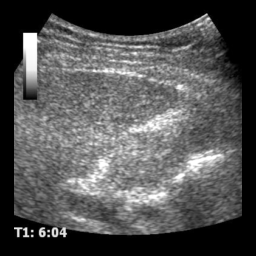

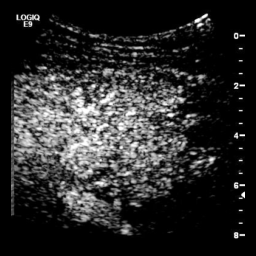

In [18]:
week3_pairs_df["panel_a_exists"] = week3_pairs_df[
    "panel_a_preprocessed_path"
].map(lambda p: Path(p).exists())

week3_pairs_df["panel_b_exists"] = week3_pairs_df[
    "panel_b_preprocessed_path"
].map(lambda p: Path(p).exists())

print("=== PREPROCESSED IMAGE CHECK ===")
print(
    "Panel A:",
    int(week3_pairs_df["panel_a_exists"].sum()),
    "/",
    len(week3_pairs_df),
)

print(
    "Panel B:",
    int(week3_pairs_df["panel_b_exists"].sum()),
    "/",
    len(week3_pairs_df),
)

sample_a = Image.open(
    week3_pairs_df.iloc[0]["panel_a_preprocessed_path"]
)

sample_b = Image.open(
    week3_pairs_df.iloc[0]["panel_b_preprocessed_path"]
)

print("Sample A size:", sample_a.size)
print("Sample B size:", sample_b.size)

display(sample_a)
display(sample_b)

Saved QC sheet: /kaggle/working/project_rooting_week3/qc/week3_preprocessed_pair_contact_sheet.png


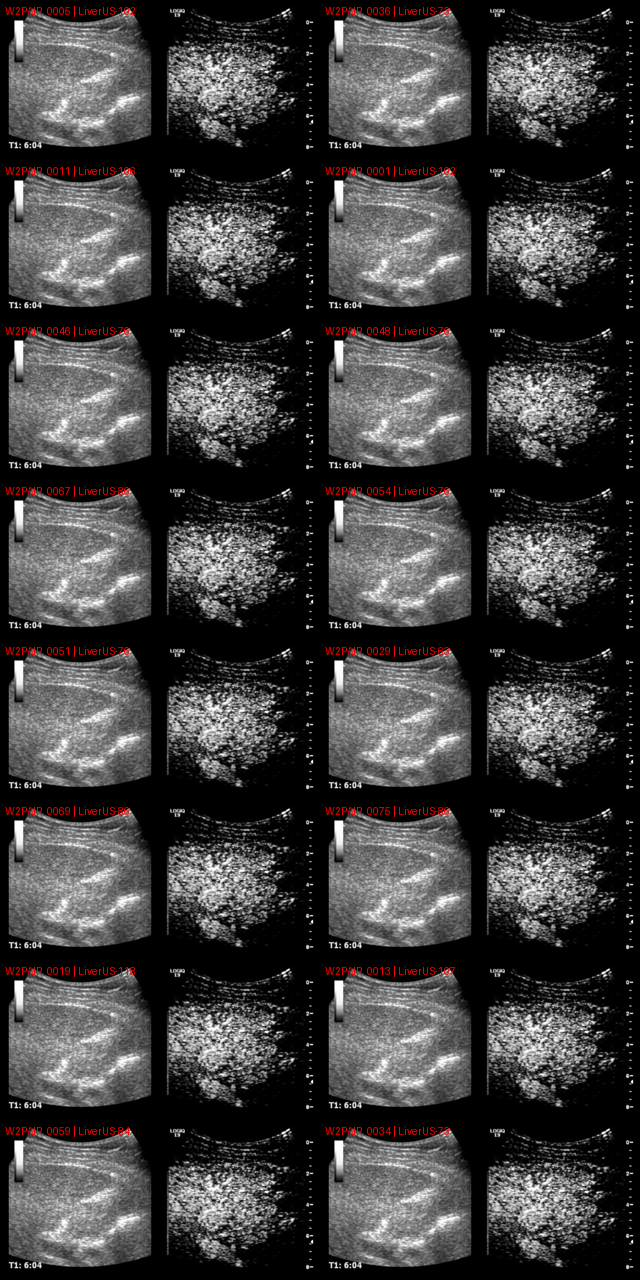

In [19]:
def make_pair_contact_sheet(
    dataframe,
    output_path,
    max_pairs=16,
    tile_size=160,
):
    sample_df = (
        dataframe
        .sample(
            n=min(max_pairs, len(dataframe)),
            random_state=SEED,
        )
        .reset_index(drop=True)
    )

    pair_images = []

    for _, row in sample_df.iterrows():
        panel_a = Image.open(
            row["panel_a_preprocessed_path"]
        ).convert("L")

        panel_b = Image.open(
            row["panel_b_preprocessed_path"]
        ).convert("L")

        panel_a = panel_a.resize((tile_size, tile_size))
        panel_b = panel_b.resize((tile_size, tile_size))

        combined = Image.new(
            "L",
            (tile_size * 2, tile_size),
            color=0,
        )

        combined.paste(panel_a, (0, 0))
        combined.paste(panel_b, (tile_size, 0))

        combined = combined.convert("RGB")
        draw = ImageDraw.Draw(combined)

        draw.text(
            (5, 5),
            f"{row['pair_id']} | {row['PatientID']}",
            fill=(255, 0, 0),
        )

        pair_images.append(combined)

    columns = 2
    rows = int(np.ceil(len(pair_images) / columns))

    sheet = Image.new(
        "RGB",
        (
            columns * tile_size * 2,
            rows * tile_size,
        ),
        color=(0, 0, 0),
    )

    for idx, image in enumerate(pair_images):
        x = (idx % columns) * tile_size * 2
        y = (idx // columns) * tile_size
        sheet.paste(image, (x, y))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path)

    return output_path


PAIR_QC_SHEET = QC_DIR / "week3_preprocessed_pair_contact_sheet.png"

make_pair_contact_sheet(
    dataframe=week3_pairs_df,
    output_path=PAIR_QC_SHEET,
    max_pairs=16,
)

print("Saved QC sheet:", PAIR_QC_SHEET)
display(Image.open(PAIR_QC_SHEET))

In [20]:
monai_datalist = {
    "name": "Project Rooting Week 3 Preprocessed Ultrasound Panel-Pair Dataset",
    "stage": "week3_preprocessing_and_dataset_construction",
    "source": "Week 2 validated paired panel candidates",
    "pairing_semantics": (
        "Panel A and Panel B are candidate paired panels derived from "
        "validated intra-DICOM split cases. They are not asserted as "
        "ground-truth B-mode/CEUS modality labels."
    ),
    "preprocessing_policy": PREPROCESSING_POLICY,
    "splits": {
        "training": [],
        "validation": [],
        "test": [],
    },
}

split_key_map = {
    "train": "training",
    "val": "validation",
    "test": "test",
}

for _, row in week3_pairs_df.iterrows():
    item = {
        "pair_id": row["pair_id"],
        "patient_id": row["PatientID"],
        "panel_a": row["panel_a_preprocessed_path"],
        "panel_b": row["panel_b_preprocessed_path"],
        "split_confidence_score": (
            None
            if pd.isna(row["split_confidence_score"])
            else float(row["split_confidence_score"])
        ),
        "split_confidence_tier": row["split_confidence_tier"],
        "split_validation_status": row["split_validation_status"],
        "pairing_status": row["pairing_status"],
        "semantic_review_status": row["semantic_review_status"],
    }

    split_key = split_key_map[row["dataset_split"]]

    monai_datalist["splits"][split_key].append(item)

MONAI_DATALIST_PATH = EXPORT_DIR / "week3_monai_datalist.json"

with open(
    MONAI_DATALIST_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(monai_datalist, f, indent=2)

print("=== MONAI DATALIST CREATED ===")
print("Training:", len(monai_datalist["splits"]["training"]))
print("Validation:", len(monai_datalist["splits"]["validation"]))
print("Test:", len(monai_datalist["splits"]["test"]))
print("Saved:", MONAI_DATALIST_PATH)

=== MONAI DATALIST CREATED ===
Training: 43
Validation: 22
Test: 12
Saved: /kaggle/working/project_rooting_week3/exports/week3_monai_datalist.json


In [21]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.4 MB/s eta 0:00:00a 0:00:01


In [22]:
from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
)

smoke_items = monai_datalist["splits"]["training"][:3]

smoke_transform = Compose([
    LoadImaged(
        keys=["panel_a", "panel_b"],
        image_only=True,
    ),
    EnsureChannelFirstd(
        keys=["panel_a", "panel_b"],
        channel_dim="no_channel",
    ),
    ScaleIntensityd(
        keys=["panel_a", "panel_b"],
    ),
])

monai_smoke_success = True
monai_smoke_error = ""

try:
    smoke_dataset = Dataset(
        data=smoke_items,
        transform=smoke_transform,
    )

    sample = smoke_dataset[0]

    print("=== MONAI SMOKE TEST ===")
    print("Pair ID:", sample["pair_id"])
    print("Panel A shape:", tuple(sample["panel_a"].shape))
    print("Panel B shape:", tuple(sample["panel_b"].shape))
    print("Panel A range:", float(sample["panel_a"].min()), float(sample["panel_a"].max()))
    print("Panel B range:", float(sample["panel_b"].min()), float(sample["panel_b"].max()))
    print("MONAI smoke test: PASS ")

except Exception as error:
    monai_smoke_success = False
    monai_smoke_error = str(error)

    print("MONAI smoke test: FAIL ")
    print(monai_smoke_error)

=== MONAI SMOKE TEST ===
Pair ID: W2PAIR_0001
Panel A shape: (1, 256, 256)
Panel B shape: (1, 256, 256)
Panel A range: 0.0 1.0
Panel B range: 0.0 1.0
MONAI smoke test: PASS 


In [23]:
validation_tests = []

def add_test(name, passed, details):
    validation_tests.append({
        "test_name": name,
        "passed": bool(passed),
        "details": str(details),
    })


add_test(
    "input_pair_count_is_77",
    len(pairing_df) == 77,
    f"pairing_df rows = {len(pairing_df)}",
)

add_test(
    "preprocessed_pair_count_matches_input",
    len(week3_pairs_df) == len(pairing_df),
    f"{len(week3_pairs_df)} / {len(pairing_df)}",
)

add_test(
    "all_preprocessed_panel_paths_exist",
    week3_pairs_df["panel_a_exists"].all()
    and week3_pairs_df["panel_b_exists"].all(),
    (
        f"A={int(week3_pairs_df['panel_a_exists'].sum())}, "
        f"B={int(week3_pairs_df['panel_b_exists'].sum())}"
    ),
)


def image_size_ok(path):
    return Image.open(path).size == (TARGET_SIZE, TARGET_SIZE)


all_sizes_ok = (
    week3_pairs_df["panel_a_preprocessed_path"].map(image_size_ok).all()
    and
    week3_pairs_df["panel_b_preprocessed_path"].map(image_size_ok).all()
)

add_test(
    "all_images_are_256x256",
    all_sizes_ok,
    f"target={TARGET_SIZE}x{TARGET_SIZE}",
)

patient_split_counts = (
    week3_pairs_df
    .groupby("PatientID")["dataset_split"]
    .nunique()
)

add_test(
    "no_patient_level_split_leakage",
    (patient_split_counts <= 1).all(),
    f"max_splits_per_patient={patient_split_counts.max()}",
)

datalist_count = (
    len(monai_datalist["splits"]["training"])
    +
    len(monai_datalist["splits"]["validation"])
    +
    len(monai_datalist["splits"]["test"])
)

add_test(
    "monai_datalist_count_matches_pairs",
    datalist_count == len(week3_pairs_df),
    f"{datalist_count} / {len(week3_pairs_df)}",
)

add_test(
    "monai_loader_smoke_test",
    monai_smoke_success,
    "PASS" if monai_smoke_success else monai_smoke_error,
)

add_test(
    "qc_contact_sheet_exists",
    PAIR_QC_SHEET.exists(),
    PAIR_QC_SHEET,
)

validation_tests_df = pd.DataFrame(validation_tests)

week3_validation_pass = bool(
    validation_tests_df["passed"].all()
)

validation_report = {
    "week": "Week 3",
    "stage": "preprocessing_and_dataset_construction",
    "validation_pass": week3_validation_pass,
    "summary": {
        "input_pairs": int(len(pairing_df)),
        "preprocessed_pairs": int(len(week3_pairs_df)),
        "patients": int(week3_pairs_df["PatientID"].nunique()),
        "target_size": TARGET_SIZE,
        "training_items": len(monai_datalist["splits"]["training"]),
        "validation_items": len(monai_datalist["splits"]["validation"]),
        "test_items": len(monai_datalist["splits"]["test"]),
    },
    "tests": validation_tests_df.to_dict(orient="records"),
    "scientific_boundary": (
        "Week 3 constructs a preprocessed MONAI-ready dataset from "
        "validated Week 2 candidate panel pairs. This does not create "
        "confirmed B-mode/CEUS ground-truth labels or stiffness estimates."
    ),
}

VALIDATION_REPORT_PATH = EXPORT_DIR / "week3_validation_report.json"

with open(
    VALIDATION_REPORT_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(validation_report, f, indent=2)

display(validation_tests_df)

print(
    "Week 3 validation:",
    "PASS " if week3_validation_pass else "FAIL "
)

print("Saved:", VALIDATION_REPORT_PATH)

,test_name,passed,details
0,input_pair_count_is_77,True,pairing_df rows = 77
1,preprocessed_pair_count_matches_input,True,77 / 77
2,all_preprocessed_panel_paths_exist,True,"A=77, B=77"
3,all_images_are_256x256,True,target=256x256
4,no_patient_level_split_leakage,True,max_splits_per_patient=1
5,monai_datalist_count_matches_pairs,True,77 / 77
6,monai_loader_smoke_test,True,PASS
7,qc_contact_sheet_exists,True,/kaggle/working/project_rooting_week3/qc/week3...


Week 3 validation: PASS 
Saved: /kaggle/working/project_rooting_week3/exports/week3_validation_report.json


In [24]:
week3_summary = {
    "week": "Week 3",
    "focus": "Preprocessing, patient-level split, and MONAI-ready dataset construction",
    "input": {
        "week2_pairs": int(len(pairing_df)),
        "patients": int(pairing_df["PatientID"].nunique()),
        "paired_panel_files": int(len(paired_files)),
        "temporal_clip_files": int(len(temporal_files)),
    },
    "outputs": {
        "preprocessed_pairs": int(len(week3_pairs_df)),
        "preprocessing_qc_rows": int(len(week3_qc_df)),
        "training_items": len(monai_datalist["splits"]["training"]),
        "validation_items": len(monai_datalist["splits"]["validation"]),
        "test_items": len(monai_datalist["splits"]["test"]),
        "validation_pass": week3_validation_pass,
    },
    "preprocessing_policy": PREPROCESSING_POLICY,
    "scientific_boundary": (
        "The dataset is suitable for AI pipeline development and MONAI loader testing. "
        "It should not be interpreted as clinically validated modality labels, "
        "stiffness measurements, or biomechanics parameters."
    ),
}

WEEK3_SUMMARY_PATH = EXPORT_DIR / "week3_summary.json"

with open(
    WEEK3_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(week3_summary, f, indent=2)

print(json.dumps(week3_summary, indent=2))

{
  "week": "Week 3",
  "focus": "Preprocessing, patient-level split, and MONAI-ready dataset construction",
  "input": {
    "week2_pairs": 77,
    "patients": 10,
    "paired_panel_files": 154,
    "temporal_clip_files": 100
  },
  "outputs": {
    "preprocessed_pairs": 77,
    "preprocessing_qc_rows": 154,
    "training_items": 43,
    "validation_items": 22,
    "test_items": 12,
    "validation_pass": true
  },
  "preprocessing_policy": {
    "target_size": 256,
    "color_mode": "grayscale",
    "normalization": "percentile_1_99_to_uint8",
    "resize_policy": "preserve_aspect_ratio_with_padding",
    "padding_value": 0,
    "output_format": "png_uint8",
    "input_source": "week2 validated paired panel candidates",
    "scientific_boundary": "Panels are validated intra-DICOM candidate pairs, not confirmed ground-truth B-mode/CEUS modality labels."
  },
  "scientific_boundary": "The dataset is suitable for AI pipeline development and MONAI loader testing. It should not be interpr

In [25]:
from pathlib import Path

WEEK3_README = PROJECT_ROOT / "README.md"

readme_text = f"""# Project Rooting — Week 3

## Focus

Week 3 focuses on preprocessing, patient-level dataset splitting, and MONAI-ready dataset construction for the ultrasound branch of Project Rooting.

This week builds directly on Week 2 outputs, which produced validated intra-DICOM paired panel candidates and temporal clip manifests.

## Input

- Week 2 paired panel candidates: {len(pairing_df)}
- Patients: {pairing_df["PatientID"].nunique()}
- Paired panel files: {len(paired_files)}
- Temporal clip files: {len(temporal_files)}

## Preprocessing Policy

- Convert panels to grayscale
- Percentile normalization using 1st–99th percentiles
- Resize with aspect-ratio preservation
- Pad to {TARGET_SIZE} × {TARGET_SIZE}
- Save outputs as PNG uint8 images

## Dataset Split

Patient-level splitting was used to avoid data leakage between training, validation, and test sets.

| Split | Items |
|---|---:|
| Training | {len(monai_datalist["splits"]["training"])} |
| Validation | {len(monai_datalist["splits"]["validation"])} |
| Test | {len(monai_datalist["splits"]["test"])} |

## Outputs

- `data-manifests/week3_preprocessed_pairs.csv`
- `data-manifests/week3_preprocessing_qc_metrics.csv`
- `data-manifests/week3_patient_split.csv`
- `data-manifests/week3_patient_level_split_summary.csv`
- `exports/week3_preprocessing_policy.json`
- `exports/week3_monai_datalist.json`
- `exports/week3_validation_report.json`
- `exports/week3_summary.json`
- `qc/week3_preprocessed_pair_contact_sheet.png`

## Validation

Week 3 validation status: {"PASS" if week3_validation_pass else "FAIL"}

Validation checks included:

- Input pair count check
- Preprocessed output count check
- File existence check
- Image size check
- Patient-level leakage check
- MONAI datalist consistency check
- MONAI loader smoke test
- QC contact sheet generation

## Scientific Boundary

Week 3 constructs a preprocessed MONAI-ready dataset from Week 2 validated candidate panel pairs.

The paired panels should still be interpreted as candidate intra-DICOM paired panels, not confirmed ground-truth B-mode/CEUS modality labels.

This stage does not estimate stiffness, elastography values, or biomechanical parameters.
"""

WEEK3_README.write_text(readme_text, encoding="utf-8")

print("README saved:", WEEK3_README)
print(readme_text)

README saved: /kaggle/working/project_rooting_week3/README.md
# Project Rooting — Week 3

## Focus

Week 3 focuses on preprocessing, patient-level dataset splitting, and MONAI-ready dataset construction for the ultrasound branch of Project Rooting.

This week builds directly on Week 2 outputs, which produced validated intra-DICOM paired panel candidates and temporal clip manifests.

## Input

- Week 2 paired panel candidates: 77
- Patients: 10
- Paired panel files: 154
- Temporal clip files: 100

## Preprocessing Policy

- Convert panels to grayscale
- Percentile normalization using 1st–99th percentiles
- Resize with aspect-ratio preservation
- Pad to 256 × 256
- Save outputs as PNG uint8 images

## Dataset Split

Patient-level splitting was used to avoid data leakage between training, validation, and test sets.

| Split | Items |
|---|---:|
| Training | 43 |
| Validation | 22 |
| Test | 12 |

## Outputs

- `data-manifests/week3_preprocessed_pairs.csv`
- `data-manifests/week3_preproces

In [26]:
import zipfile
from pathlib import Path

GITHUB_ZIP = Path("/kaggle/working/week3_github_package.zip")

folders_to_include = [
    PROJECT_ROOT / "data-manifests",
    PROJECT_ROOT / "exports",
    PROJECT_ROOT / "qc",
]

files_to_include = [
    PROJECT_ROOT / "README.md",
]

with zipfile.ZipFile(
    GITHUB_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for folder in folders_to_include:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                archive_name = (
                    Path("week3")
                    / file_path.relative_to(PROJECT_ROOT)
                )

                zip_file.write(
                    file_path,
                    arcname=archive_name,
                )

    for file_path in files_to_include:
        if file_path.exists():
            archive_name = (
                Path("week3")
                / file_path.relative_to(PROJECT_ROOT)
            )

            zip_file.write(
                file_path,
                arcname=archive_name,
            )

print("GitHub package created:", GITHUB_ZIP)
print(
    "Size:",
    round(GITHUB_ZIP.stat().st_size / 1024**2, 2),
    "MB",
)

GitHub package created: /kaggle/working/week3_github_package.zip
Size: 0.48 MB


In [27]:
FULL_WEEK3_ZIP = Path("/kaggle/working/week3_full_outputs_for_week4.zip")

with zipfile.ZipFile(
    FULL_WEEK3_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for file_path in PROJECT_ROOT.rglob("*"):
        if file_path.is_file():
            archive_name = (
                Path("project_rooting_week3")
                / file_path.relative_to(PROJECT_ROOT)
            )

            zip_file.write(
                file_path,
                arcname=archive_name,
            )

print("Full Week 3 package created:", FULL_WEEK3_ZIP)
print(
    "Size:",
    round(FULL_WEEK3_ZIP.stat().st_size / 1024**2, 2),
    "MB",
)

Full Week 3 package created: /kaggle/working/week3_full_outputs_for_week4.zip
Size: 5.49 MB
